# Efficient LLM Serving at Scale with Unified Caching (vLLM + LMCache)

**The idea:** vLLM keeps its prefix (KV) cache in GPU memory. When many long requests overflow that GPU pool, their KV gets **evicted and recomputed** on every reuse. LMCache adds a **CPU-DRAM tier**: evicted KV is **reloaded from host memory** instead of recomputed, cutting time-to-first-token (TTFT).

**The experiment:** run one overflow workload twice -- a cold pass, then an identical warm pass -- under two servers:

## 1. LMCache is prebuilt in the image

This notebook runs inside the prebuilt image (built on `vllm/vllm-openai-rocm:v0.23.0`). It already contains:

- **LMCache v0.5.0 compiled with `BUILD_WITH_HIP=1`** 
- **Qwen3-8B** staged 


## 2. Baseline server -- vLLM prefix cache only

`--gpu-memory-utilization 0.5` keeps the GPU KV pool small so the 24x32K workload overflows it and evicted KV is recomputed on reuse. Prefix caching is on by default in vLLM. The server launches in the background; the next cell waits for it.

In [1]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null || true

# Baseline: vLLM with its default in-GPU prefix cache, no CPU offload.
# --gpu-memory-utilization 0.5 keeps the GPU KV pool small so the 24x32K-token
# workload overflows it -- evicted KV then has to be recomputed on reuse.
nohup vllm serve Qwen/Qwen3-8B \
  --served-model-name Qwen3-8B \
  --tensor-parallel-size 1 \
  --max-model-len 32768 \
  --gpu-memory-utilization 0.5 \
  --port 8100 \
  > /tmp/vllm.log 2>&1 &
echo "launching baseline server (log: /tmp/vllm.log); first boot ~2-3 min"

launching baseline server (log: /tmp/vllm.log); first boot ~2-3 min


## 3. Wait for the server (live log)

Polls `/v1/models` and prints the tail of the server log each attempt, so you can watch weight-load → compile → ready.

In [2]:
import time, requests, subprocess
for i in range(80):
    try:
        if requests.get("http://localhost:8100/v1/models", timeout=5).ok:
            print("\n==> server ready"); break
    except requests.RequestException:
        pass
    tail = subprocess.run(["tail","-n","3","/tmp/vllm.log"], capture_output=True, text=True).stdout
    print(f"--- waiting {i+1}/80 ---\n{tail}", flush=True)
    time.sleep(10)
else:
    raise RuntimeError("server did not start - see /tmp/vllm.log")

--- waiting 1/80 ---

--- waiting 2/80 ---

--- waiting 3/80 ---
(APIServer pid=105) INFO 07-23 21:30:56 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
(APIServer pid=105) INFO 07-23 21:30:56 [vllm.py:999] Asynchronous scheduling is enabled.
(APIServer pid=105) INFO 07-23 21:30:56 [kernel.py:270] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])

--- waiting 4/80 ---
(EngineCore pid=709) INFO 07-23 21:31:06 [parallel_state.py:1903] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, PCP rank 0, TP rank 0, EP rank N/A, EPLB rank N/A
(EngineCore pid=709) INFO 07-23 21:31:06 [gpu_worker.py:303] Using V2 Model Runner
(EngineCore pid=709) INFO 07-23 21:31:07 [model_runner.py:298] Loading model from scratch...

--- waiting 5/80 ---
(EngineCore pid=709) 
(EngineCore pid=709) INFO 07-23 21:31:14 [default_loader.py:397] Loading weights took 6.54 seconds
(EngineCore pid=709) INFO 0

## 4. Benchmark the baseline (two passes)

`vllm bench serve` with a fixed `--seed`, run twice: **PASS 1 (cold)** populates the cache and **PASS 2 (warm)** re-sends the identical prompts. Because the working set overflows the GPU pool, **PASS 2 ~ PASS 1** for the baseline -- evicted KV is recomputed, so warming gives no benefit.

In [4]:
import subprocess, re, sys

def bench():
    cmd = ["vllm","bench","serve",
        "--model","Qwen3-8B","--tokenizer","Qwen/Qwen3-8B",
        "--base-url","http://localhost:8100","--endpoint","/v1/completions",
        "--dataset-name","random","--random-input-len","32000","--random-output-len","64",
        "--num-prompts","24","--max-concurrency","4","--seed","555","--ignore-eos",
        "--percentile-metrics","ttft"]
    # Stream stdout live (so you see progress) while capturing it to parse Mean TTFT.
    lines = []
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
        lines.append(line)
    proc.wait()
    out = "".join(lines)
    m = re.search(r"Mean TTFT \(ms\):\s*([0-9.]+)", out)
    return float(m.group(1))/1000 if m else None

prefix_cold = bench(); print(f"prefix-only  PASS1 cold: {prefix_cold:6.2f} s")
prefix_warm = bench(); print(f"prefix-only  PASS2 warm: {prefix_warm:6.2f} s   ({prefix_cold/prefix_warm:.2f}x)")

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7fa1632f23e0>, trust_remote_code=False, seed=555, num_prompts=24, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=32000, random_output_len=64, random_range_ratio='0.0', random_prefix_len=0, random_batch_si

## 5. Restart with LMCache -- prefix cache + CPU KV offload

A separate `lmcache server` holds KV in CPU DRAM; vLLM talks to it via `LMCacheMPConnector`. Same model and same GPU budget as the baseline -- the only change is the added CPU cache tier.

In [5]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null && sleep 2 || true

# CPU-DRAM KV cache server. --l1-size-gb pins that many GiB of host RAM up front,
# so it must fit comfortably in available RAM.
nohup lmcache server \
  --host 127.0.0.1 --port 5555 \
  --l1-size-gb 150 --eviction-policy LRU --chunk-size 256 \
  > /tmp/lmcache_server.log 2>&1 &
sleep 6

# Same vLLM server as the baseline, now pointed at the LMCache server so evicted
# KV is offloaded to (and reloaded from) CPU DRAM instead of being recomputed.
nohup vllm serve Qwen/Qwen3-8B \
  --served-model-name Qwen3-8B \
  --tensor-parallel-size 1 \
  --max-model-len 32768 \
  --gpu-memory-utilization 0.5 \
  --port 8100 \
  --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both"}' \
  > /tmp/vllm.log 2>&1 &
echo "launching prefix+LMCache server; first boot ~2-3 min"

launching prefix+LMCache server; first boot ~2-3 min


## 6. Wait for the LMCache server

In [6]:
import time, requests, subprocess
for i in range(80):
    try:
        if requests.get("http://localhost:8100/v1/models", timeout=5).ok:
            print("\n==> server ready"); break
    except requests.RequestException:
        pass
    tail = subprocess.run(["tail","-n","3","/tmp/vllm.log"], capture_output=True, text=True).stdout
    print(f"--- waiting {i+1}/80 ---\n{tail}", flush=True)
    time.sleep(10)
else:
    raise RuntimeError("server did not start - see /tmp/vllm.log")

--- waiting 1/80 ---

--- waiting 2/80 ---
(APIServer pid=2535) [2026-07-23 21:43:36,819] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:120:lmcache)
(APIServer pid=2535) [2026-07-23 21:43:36,873] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)
(APIServer pid=2535) [2026-07-23 21:43:36,884] LMCache INFO: Using external LMCacheMPConnector from lmcache.integration.vllm.lmcache_mp_connector (lmcache_mp_connector.py:1212:vllm.distributed.kv_transfer.kv_connector.v1.lmcache_mp_connector)

--- waiting 3/80 ---
(EngineCore pid=2820) 
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:03<00:05,  1.68s/it]
(EngineCore pid=2820) 
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:04<00:03,  1.66s/it]
(EngineCore pid=2820) 
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:06<00:01,  1.53s/it]

--- waiting 4/80 ---
(EngineCore pid=2820) INFO 07-23 21:43:54 [model_runner.py:319] Model 

## 7. Benchmark with LMCache (same two passes)

Identical workload. Now **PASS 2 << PASS 1**: evicted KV is reloaded from CPU instead of recomputed, so the warm pass drops sharply.

In [11]:
import subprocess, re, sys

def bench():
    cmd = ["vllm","bench","serve",
        "--model","Qwen3-8B","--tokenizer","Qwen/Qwen3-8B",
        "--base-url","http://localhost:8100","--endpoint","/v1/completions",
        "--dataset-name","random","--random-input-len","32000","--random-output-len","64",
        "--num-prompts","24","--max-concurrency","4","--seed","555","--ignore-eos",
        "--percentile-metrics","ttft"]
    # Stream stdout live (so you see progress) while capturing it to parse Mean TTFT.
    lines = []
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
        lines.append(line)
    proc.wait()
    out = "".join(lines)
    m = re.search(r"Mean TTFT \(ms\):\s*([0-9.]+)", out)
    return float(m.group(1))/1000 if m else None

lmcache_cold = bench(); print(f"LMCache  PASS1 cold: {lmcache_cold:6.2f} s")
lmcache_warm = bench(); print(f"LMCache  PASS2 warm: {lmcache_warm:6.2f} s   ({lmcache_cold/lmcache_warm:.2f}x)")

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7fbeb94c23e0>, trust_remote_code=False, seed=555, num_prompts=24, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=32000, random_output_len=64, random_range_ratio='0.0', random_prefix_len=0, random_batch_si

## 8. Proof it was the cache

LMCache exposes cache activity on its Prometheus endpoint (`:8080/metrics`). On the warm pass, `lmcache_mp_lookup_hit_tokens_total` climbs above 0 -- evicted KV was **reloaded from CPU**, not recomputed. If `requested` grows but `hit` stays 0, the cache keys are not matching between passes.

In [8]:
%%bash
# LMCache reports cache activity via its Prometheus endpoint (:8080/metrics),
# not the server log. lookup_hit_tokens climbing > 0 on the warm pass is the
# proof that evicted KV was reloaded from CPU instead of recomputed.
echo "---- store activity (server log) ----"
grep -cE "Stored [0-9]+ tokens" /tmp/lmcache_server.log | sed 's/^/store ops: /'
echo "---- lookup hits vs requests (metrics) ----"
curl -s http://localhost:8080/metrics \
  | grep -E "lmcache_mp_lookup_(hit|requested)_tokens_total" \
  | grep -v '^#' || echo "metrics endpoint not reachable"

---- store activity (server log) ----
store ops: 114
---- lookup hits vs requests (metrics) ----
lmcache_mp_lookup_requested_tokens_total{cache_salt="",model_name="Qwen/Qwen3-8B"} 1.536e+06
lmcache_mp_lookup_hit_tokens_total{cache_salt="",model_name="Qwen/Qwen3-8B"} 768000.0


## 9. The warm-pass result

The cold pass only populates the cache, so it is not plotted. The **warm pass** is the story: prefix-only stays high because it recomputes the evicted KV, while prefix+LMCache drops sharply because it reloads that KV from CPU. The right panel headlines the speedup.

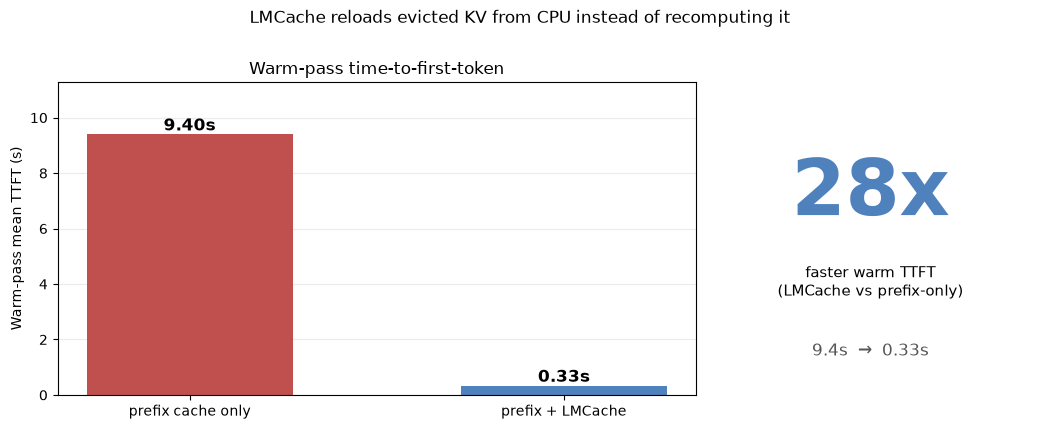

Warm TTFT: prefix-only 9.40s vs LMCache 0.33s -> 28.4x faster


In [9]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--root-user-action=ignore", "matplotlib"])

import matplotlib.pyplot as plt
import numpy as np

# Warm pass only -- the cold pass merely populates the cache; the warm pass is the result.
labels = ["prefix cache only", "prefix + LMCache"]
warm   = [prefix_warm, lmcache_warm]
warm_speedup = prefix_warm / lmcache_warm
C_PREFIX, C_LMC = "#c0504d", "#4f81bd"

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2),
                              gridspec_kw={"width_ratios": [2, 1]})

# Panel 1 -- warm-pass TTFT, one bar per server
x = np.arange(2)
bars = ax.bar(x, warm, width=0.55, color=[C_PREFIX, C_LMC])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Warm-pass mean TTFT (s)")
ax.set_title("Warm-pass time-to-first-token")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.set_ylim(0, max(warm) * 1.2)
for b, v in zip(bars, warm):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

# Panel 2 -- speedup headline
ax2.axis("off")
ax2.text(0.5, 0.64, f"{warm_speedup:.0f}x", ha="center", va="center",
         fontsize=56, fontweight="bold", color=C_LMC)
ax2.text(0.5, 0.36, "faster warm TTFT\n(LMCache vs prefix-only)",
         ha="center", va="center", fontsize=11)
ax2.text(0.5, 0.14, f"{prefix_warm:.1f}s  \u2192  {lmcache_warm:.2f}s",
         ha="center", va="center", fontsize=12, color="#555")

fig.suptitle("LMCache reloads evicted KV from CPU instead of recomputing it",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"Warm TTFT: prefix-only {prefix_warm:.2f}s vs LMCache {lmcache_warm:.2f}s "
      f"-> {warm_speedup:.1f}x faster")

## 10. When does LMCache help?

Only when **both** hold:

| Condition | Why |
|---|---|
| **Long context reused** | Reload only pays off when recompute (long prefill) is expensive. |
| **GPU HBM under pressure** | If the working set fits in GPU, vLLM's prefix cache already serves reuse and LMCache just adds transfer cost. |

That is why this demo overflows a small GPU pool with long requests. With a single short request, or a GPU pool large enough to hold the working set, prefix caching alone is enough and LMCache shows no benefit -- that is expected.

## 11. How LMCache works — animated walkthrough

Before the live demo, here is a step-by-step animation of the exact mechanism the benchmarks above exercise: how LMCache splits a request's KV into **256-token chunks**, **spills** them *down* the memory hierarchy (GPU VRAM → CPU DRAM → local SSD → remote) as memory fills, and then **loads them back up** when a later request reuses the same prefix — recomputing only the one genuinely new chunk.

Step through the 13 stages with the **arrow keys / space** or the on-screen controls. It renders in JupyterLab / Notebook with a live kernel (the animation is a self-contained HTML/JS widget embedded via an iframe); it will not render in a static GitHub/nbviewer preview.

In [10]:
from pathlib import Path
from IPython.display import HTML
import html as _html

# Embed the self-contained HTML/JS walkthrough in an iframe so its <script> runs
# inside the notebook. Use arrow keys / space (or the on-screen buttons) to step.
_anim = Path("lmcache-animation.html").read_text(encoding="utf-8")
HTML(f'<iframe srcdoc="{_html.escape(_anim, quote=True)}" '
     f'style="width:100%;height:900px;border:1px solid #27314f;border-radius:12px" '
     f'title="How LMCache Works"></iframe>')

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:446: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 12. Live side-by-side: one prompt, two servers on one GPU

The benchmark above ran the two configurations one after another. Here we run them **at the same time** — a baseline vLLM (prefix cache only) on port 8101 and an LMCache-backed vLLM on port 8100, both serving Qwen3-8B on the **same GPU**.

To fit two copies on one GPU we shrink each one's footprint: `--max-model-len 32768` (enough for the ~30K-token document) plus a small, fixed KV pool (`--num-gpu-blocks-override 2560`, ~40K tokens). That small pool is also what makes the demo work — a long shared document gets **evicted from the baseline's GPU cache** by later traffic, while LMCache keeps it in CPU DRAM.

We then send **one identical request** (the document + a question) to both and compare time-to-first-token: the baseline recomputes the whole document, LMCache reloads it from CPU.

In [12]:
%%bash
pkill -f "vllm serve" 2>/dev/null && sleep 4 || true
pkill -f "lmcache server" 2>/dev/null && sleep 2 || true

wait_ready () {  # $1=port $2=log $3=name
  for i in $(seq 1 60); do
    [ "$(curl -s -o /dev/null -w '%{http_code}' --max-time 3 http://localhost:$1/v1/models 2>/dev/null)" = "200" ] && { echo "==> $3 ready"; return 0; }
    grep -qE "No available memory|Engine core initialization failed" "$2" && { echo "$3 BOOT ERROR (see $2)"; return 1; }
    echo "--- $3 waiting $i/60 ---"; tail -n 2 "$2" 2>/dev/null
    sleep 5
  done; echo "$3 timeout"; return 1
}

# CPU-DRAM KV server for the LMCache side
nohup lmcache server --host 127.0.0.1 --port 5555 \
  --l1-size-gb 40 --eviction-policy LRU --chunk-size 256 \
  > /tmp/lmcache_server.log 2>&1 &
sleep 6

# Both servers share one GPU. max-model-len 32768 fits the ~30K-token document,
# and a forced ~40K-token KV pool (2560 blocks x 16 tok) holds one doc when primed
# but is small enough that filler traffic evicts it.
COMMON="--tensor-parallel-size 1 --max-model-len 32768 --gpu-memory-utilization 0.35 \
  --num-gpu-blocks-override 2560 --max-num-batched-tokens 4096 --max-num-seqs 8 --enforce-eager"

# Boot sequentially (each fully up before the next) so their memory profiling doesn't collide.
nohup vllm serve Qwen/Qwen3-8B --served-model-name Qwen3-8B $COMMON \
  --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both"}' \
  --port 8100 > /tmp/vllm_lmcache.log 2>&1 &
wait_ready 8100 /tmp/vllm_lmcache.log "LMCache server (:8100)" || exit 1

nohup vllm serve Qwen/Qwen3-8B --served-model-name Qwen3-8B $COMMON \
  --port 8101 > /tmp/vllm_baseline.log 2>&1 &
wait_ready 8101 /tmp/vllm_baseline.log "baseline server (:8101)" || exit 1

grep -m1 "GPU KV cache size" /tmp/vllm_lmcache.log
echo "both servers up on one GPU"

--- LMCache server (:8100) waiting 1/60 ---
--- LMCache server (:8100) waiting 2/60 ---
--- LMCache server (:8100) waiting 3/60 ---
(APIServer pid=4722) [2026-07-23 21:49:51,626] LMCache INFO: Using external LMCacheMPConnector from lmcache.integration.vllm.lmcache_mp_connector (lmcache_mp_connector.py:1212:vllm.distributed.kv_transfer.kv_connector.v1.lmcache_mp_connector)
(APIServer pid=4722) INFO 07-23 21:49:51 [compilation.py:321] Enabled custom fusions: norm_quant, act_quant
--- LMCache server (:8100) waiting 4/60 ---
(APIServer pid=4722) [2026-07-23 21:49:51,626] LMCache INFO: Using external LMCacheMPConnector from lmcache.integration.vllm.lmcache_mp_connector (lmcache_mp_connector.py:1212:vllm.distributed.kv_transfer.kv_connector.v1.lmcache_mp_connector)
(APIServer pid=4722) INFO 07-23 21:49:51 [compilation.py:321] Enabled custom fusions: norm_quant, act_quant
--- LMCache server (:8100) waiting 5/60 ---
(EngineCore pid=5022) INFO 07-23 21:50:02 [weight_utils.py:945] Auto-prefetch 

In [13]:
import time, json, re, threading, requests
from transformers import AutoTokenizer

MODEL_DIR = "Qwen/Qwen3-8B"
LMC, BASE = "http://localhost:8100", "http://localhost:8101"
tok = AutoTokenizer.from_pretrained(MODEL_DIR)
ntok = lambda s: len(tok(s)["input_ids"])

def make_doc(theme, target_tokens):
    """A distinct, ~target_tokens 'document' of synthetic notes (used for filler/eviction)."""
    out, i = [], 0
    while ntok("\n".join(out)) < target_tokens:
        out.append(f"[{theme}] Note {i}: In the {theme} subsystem, record {i} tracks metric "
                   f"{(i*7)%97} against threshold {(i*13)%89}, with owner team {chr(65+i%26)} "
                   f"reviewing rollout {i} for latency, cache behavior, and throughput.")
        i += 1
    return "\n".join(out)

def load_document(target_tokens, local_file="amd_doc.txt", title="Advanced Micro Devices"):
    """Load the demo document, trimmed to ~target_tokens. Prefers the bundled
    local file (no download); falls back to a live Wikipedia fetch, then to a
    synthetic doc if both are unavailable."""
    # 1) bundled local file (ships with the notebook -- no network needed)
    try:
        text = open(local_file, encoding="utf-8").read()
        ids = tok(text)["input_ids"][:target_tokens]
        return tok.decode(ids), f"local file: {local_file}"
    except Exception:
        pass
    # 2) live Wikipedia fetch
    try:
        r = requests.get("https://en.wikipedia.org/w/api.php",
                         params={"action":"query","prop":"extracts","explaintext":1,
                                 "titles":title,"format":"json","redirects":1},
                         headers={"User-Agent":"lmcache-workshop-demo/1.0"}, timeout=30)
        text = next(iter(r.json()["query"]["pages"].values()))["extract"]
        ids = tok(text)["input_ids"][:target_tokens]
        return tok.decode(ids), f"Wikipedia: {title}"
    except Exception as e:
        print(f"(document load failed: {e}; falling back to synthetic doc)")
        return make_doc("amd", target_tokens), "synthetic fallback"

def chat(url, doc, question, stream=False, max_tokens=128):
    body = {"model": "Qwen3-8B",
            "messages": [{"role": "system", "content": doc}, {"role": "user", "content": question}],
            "max_tokens": max_tokens, "temperature": 0, "stream": stream,
            "chat_template_kwargs": {"enable_thinking": False}}
    if not stream:
        return requests.post(url + "/v1/chat/completions", json=body, timeout=300
                             ).json()["choices"][0]["message"]["content"]
    t0, ttft, text = time.time(), None, []
    with requests.post(url + "/v1/chat/completions", json=body, stream=True, timeout=300) as r:
        for line in r.iter_lines():
            if not line:
                continue
            line = line.decode()
            if not line.startswith("data:"):
                continue
            payload = line[5:].strip()
            if payload == "[DONE]":
                break
            delta = json.loads(payload)["choices"][0]["delta"].get("content", "")
            if delta and ttft is None:
                ttft = time.time() - t0
            if delta:
                text.append(delta)
    return ttft, "".join(text)

def hit_tokens():
    try:
        for l in requests.get("http://localhost:8080/metrics", timeout=5).text.splitlines():
            if l.startswith("lmcache_mp_lookup_hit_tokens_total"):
                return float(l.split()[-1])
    except requests.RequestException:
        pass
    return 0.0

# A real long document (the bundled AMD articles) + a question about it
DOC, DOC_SRC = load_document(30000); DOC_TOK = ntok(DOC)
QUESTION = "Based only on the document above, who founded AMD and in what year? Answer briefly."
print(f"shared document = {DOC_TOK} tokens  (source: {DOC_SRC})")

# 1) prime BOTH so each has computed the document once
for u in (LMC, BASE):
    chat(u, DOC, "Acknowledge in one word.", max_tokens=4)

# 2) evict it from the baseline's small GPU pool with distinct filler (LMCache keeps it in CPU)
try:
    pool = int(re.search(r"GPU KV cache size: ([\d,]+) tokens",
                         open("/tmp/vllm_baseline.log").read()).group(1).replace(",", ""))
except Exception:
    pool = 40960
nfill = max(2, int(pool * 1.6) // DOC_TOK + 1)
for k in range(nfill):
    f = make_doc(f"filler{k}", DOC_TOK)
    for u in (LMC, BASE):
        chat(u, f, "Acknowledge in one word.", max_tokens=4)
print(f"baseline GPU pool = {pool} tokens; sent {nfill} filler docs to evict the shared document")

# 3) ONE identical request to both, streamed and concurrent; measure time-to-first-token
h0, res = hit_tokens(), {}
def run(k, u): res[k] = chat(u, DOC, QUESTION, stream=True, max_tokens=128)
threads = [threading.Thread(target=run, args=a) for a in (("baseline", BASE), ("lmcache", LMC))]
[t.start() for t in threads]; [t.join() for t in threads]
base_ttft, base_txt = res["baseline"]
lmc_ttft,  lmc_txt  = res["lmcache"]
reloaded = hit_tokens() - h0

print(f"\nbaseline  TTFT = {base_ttft:.3f}s   -> {base_txt.strip()}")
print(f"LMCache   TTFT = {lmc_ttft:.3f}s   -> {lmc_txt.strip()}")
print(f"speedup = {base_ttft / lmc_ttft:.1f}x   |  {reloaded:.0f} document tokens reloaded from CPU")

shared document = 30000 tokens  (source: local file: amd_doc.txt)
baseline GPU pool = 40960 tokens; sent 3 filler docs to evict the shared document

baseline  TTFT = 2.898s   -> Advanced Micro Devices (AMD) was founded by Jerry Sanders and seven of his colleagues from Fairchild Semiconductor in 1969.
LMCache   TTFT = 0.365s   -> Advanced Micro Devices (AMD) was founded by Jerry Sanders and seven of his colleagues from Fairchild Semiconductor in 1969.
speedup = 7.9x   |  29952 document tokens reloaded from CPU


In [14]:
from IPython.display import HTML, display

speedup = base_ttft / lmc_ttft

def bubble(name, color, ttft, text, fast):
    tag = "&#9889; fastest" if fast else "&nbsp;"
    return f"""<div style="flex:1;min-width:240px;border:1px solid #e3e8ee;border-radius:12px;overflow:hidden">
      <div style="background:{color};color:#fff;padding:10px 14px;font-weight:600;display:flex;justify-content:space-between">
        <span>{name}</span><span style="font-weight:500;opacity:.9">{tag}</span></div>
      <div style="padding:12px 14px">
        <span style="display:inline-block;background:#eef2f7;border-radius:999px;padding:3px 10px;font-size:12px;color:#334;margin-bottom:10px">first token in <b>{ttft:.2f}s</b></span>
        <div style="background:#f7f9fb;border-radius:10px;padding:10px 12px;font-size:14px;line-height:1.5;color:#111">{text}</div>
      </div></div>"""

html = f"""<div style="font-family:-apple-system,Segoe UI,Roboto,sans-serif;max-width:780px">
  <div style="font-size:12px;color:#667;letter-spacing:.05em;text-transform:uppercase;margin-bottom:6px">One request &rarr; two servers on one GPU</div>
  <div style="background:#eef2f7;border-radius:12px;padding:12px 14px;margin-bottom:12px;font-size:14px;color:#111">
    <b>User:</b> {QUESTION}<br><span style="color:#8892a0">(with a {DOC_TOK:,}-token document as shared context)</span></div>
  <div style="display:flex;gap:12px;flex-wrap:wrap">
    {bubble("Baseline &mdash; prefix cache only", "#c0504d", base_ttft, base_txt.strip() or "(no text)", base_ttft < lmc_ttft)}
    {bubble("Prefix + LMCache", "#4f81bd", lmc_ttft, lmc_txt.strip() or "(no text)", lmc_ttft < base_ttft)}
  </div>
  <div style="margin-top:14px;text-align:center;font-size:15px;color:#111">
    Same answer, same GPU &mdash; LMCache&rsquo;s first token is
    <b style="color:#4f81bd">{speedup:.1f}&times; faster</b>
    ({base_ttft:.2f}s &rarr; {lmc_ttft:.2f}s), reloading <b>{reloaded:,.0f}</b> tokens from CPU instead of recomputing them.</div>
</div>"""
display(HTML(html))

## 13. Try it yourself — interactive

Run this cell in **JupyterLab** (or classic Jupyter Notebook) with a **live kernel** — the two servers from cell 12 must still be running. Type a question about the document and press **Enter** (or click **Ask both**); both answers stream back with their time-to-first-token, side by side.

> **Needs `ipywidgets`.** The cell installs it automatically, but if the input box doesn't appear the first time, do **Kernel → Restart Kernel**, then re-run this cell (the widgets frontend loads at kernel start). Widgets do **not** render in VS Code's static preview, on GitHub, or in nbviewer.

Before each question the shared document is evicted from both GPUs, so the baseline recomputes it while LMCache reloads it from CPU — that's why the gap shows up on *every* question, not just the first.

In [ ]:
import sys, subprocess, threading, time, json, requests
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--root-user-action=ignore", "ipywidgets"])
import ipywidgets as widgets
from IPython.display import display

ANSWER_STYLE = "Answer in one or two complete sentences."   # appended to the user turn

# Distinct doc used to evict the shared document from GPU before each question,
# so every question shows baseline-recompute vs LMCache-CPU-reload. Sized to fill
# the GPU KV pool (>= the ~30K shared doc) so the baseline is fully evicted.
EVICTOR = make_doc("evictor", 31000)

# Prime once so LMCache's CPU tier holds the document even for the first question.
for _u in (LMC, BASE):
    chat(_u, DOC, "ok", max_tokens=2)

C_BASE, C_LMC = "#c0504d", "#4f81bd"

def _panel(title, color, ttft, text, tag=""):
    ttft_html = f"{ttft:.2f}s" if ttft is not None else "…"
    badge = (f'<span style="background:rgba(255,255,255,.25);border-radius:999px;'
             f'padding:2px 10px;font-size:12px;font-weight:600">{tag}</span>' if tag else "")
    return (f'<div style="flex:1;min-width:260px;border:1px solid #e3e8ee;border-radius:14px;overflow:hidden;box-shadow:0 1px 4px rgba(0,0,0,.06)">'
            f'<div style="background:{color};color:#fff;padding:12px 16px;display:flex;justify-content:space-between;align-items:center">'
            f'<span style="font-weight:700">{title}</span>{badge}</div>'
            f'<div style="padding:14px 16px">'
            f'<div style="font-size:34px;font-weight:800;color:{color};line-height:1">{ttft_html}'
            f'<span style="font-size:13px;font-weight:500;color:#8892a0"> to first token</span></div>'
            f'<div style="margin-top:12px;background:#f7f9fb;border-radius:10px;padding:12px 14px;'
            f'font-size:14px;line-height:1.55;color:#111;min-height:56px">{text}</div>'
            f'</div></div>')

def _render(question, st, reloaded=None):
    b, l = st["b"], st["l"]
    done = b["done"] and l["done"]
    btag = ltag = ""
    if done and b["ttft"] is not None and l["ttft"] is not None:
        if l["ttft"] < b["ttft"]: ltag = "⚡ faster"
        elif b["ttft"] < l["ttft"]: btag = "⚡ faster"
    foot = ""
    if done and b["ttft"] and l["ttft"]:
        speed = b["ttft"] / l["ttft"]
        foot = (f'<div style="margin-top:16px;text-align:center;font-size:16px;color:#111">'
                f'LMCache first token <b style="color:{C_LMC}">{speed:.1f}× faster</b> '
                f'({b["ttft"]:.2f}s → {l["ttft"]:.2f}s)'
                + (f' — <b>{reloaded:,.0f}</b> tokens reloaded from CPU instead of recomputed'
                   if reloaded else '') + '</div>')
    return (f'<div style="font-family:-apple-system,Segoe UI,Roboto,sans-serif;max-width:900px">'
            f'<div style="background:#eef2f7;border-radius:12px;padding:12px 16px;margin-bottom:14px;font-size:15px;color:#111">'
            f'<b>You:</b> {question}</div>'
            f'<div style="display:flex;gap:14px;flex-wrap:wrap">'
            f'{_panel("Baseline (prefix cache only)", C_BASE, b["ttft"], (b["text"] or "…"), btag)}'
            f'{_panel("Prefix + LMCache", C_LMC, l["ttft"], (l["text"] or "…"), ltag)}'
            f'</div>{foot}</div>')

def _stream(url, doc, question, key, st, lock, refresh, max_tokens=248):
    """Stream one server's answer, updating shared state token-by-token.
    The format instruction goes in the user turn so the cached doc prefix is unchanged."""
    body = {"model": "Qwen3-8B",
            "messages": [{"role": "system", "content": doc},
                         {"role": "user", "content": f"{question}\n\n{ANSWER_STYLE}"}],
            "max_tokens": max_tokens, "temperature": 0, "stream": True,
            "chat_template_kwargs": {"enable_thinking": False}}
    t0 = time.time()
    with requests.post(url + "/v1/chat/completions", json=body, stream=True, timeout=300) as r:
        for line in r.iter_lines():
            if not line:
                continue
            line = line.decode()
            if not line.startswith("data:"):
                continue
            payload = line[5:].strip()
            if payload == "[DONE]":
                break
            delta = json.loads(payload)["choices"][0]["delta"].get("content", "")
            if not delta:
                continue
            with lock:
                if st[key]["ttft"] is None:
                    st[key]["ttft"] = time.time() - t0
                st[key]["text"] += delta
            refresh()
    with lock:
        st[key]["done"] = True
    refresh(force=True)

q_box  = widgets.Text(placeholder="Ask a question about AMD, then press Enter",
                      layout=widgets.Layout(width="72%"), continuous_update=False)
ask    = widgets.Button(description="Ask both", button_style="primary", icon="paper-plane")
status = widgets.HTML()
panel  = widgets.HTML()          # results render here (thread-safe via .value)
_busy  = {"v": False}

def _on_ask(*_):
    if _busy["v"]:
        return
    question = (q_box.value or "").strip() or QUESTION
    _busy["v"] = True; ask.disabled = True
    status.value = '<span style="color:#8892a0"><i>Evicting document from GPU, then streaming both answers live…</i></span>'
    st = {"b": {"ttft": None, "text": "", "done": False},
          "l": {"ttft": None, "text": "", "done": False}}
    lock = threading.Lock()
    last = {"t": 0.0, "rel": None}
    def refresh(force=False):
        now = time.time()
        if not force and now - last["t"] < 0.05:   # throttle to ~20 fps
            return
        last["t"] = now
        panel.value = _render(question, st, last["rel"])
    refresh(force=True)                              # show empty panels immediately
    def work():
        try:
            for _u in (LMC, BASE):                   # re-evict from both GPUs each turn
                chat(_u, EVICTOR, "ok", max_tokens=2)
            h0 = hit_tokens()
            ts = [threading.Thread(target=_stream, args=(u, DOC, question, k, st, lock, refresh))
                  for k, u in (("b", BASE), ("l", LMC))]
            [t.start() for t in ts]; [t.join() for t in ts]
            last["rel"] = hit_tokens() - h0
            refresh(force=True)
            status.value = ""
        except Exception as e:
            status.value = (f'<span style="color:#b04a47">error: {e} '
                            f'— are both servers from cell 12 still running?</span>')
        finally:
            _busy["v"] = False; ask.disabled = False
    threading.Thread(target=work).start()

ask.on_click(_on_ask)
# Enter in the text box submits (continuous_update=False -> value fires on Enter/blur).
q_box.observe(lambda ch: _on_ask() if ch["name"] == "value" and ch["new"].strip() else None, names="value")

print("Ask a question about AMD (e.g. 'When was AMD founded?', 'What is Instinct?') and press Enter.")
display(widgets.HBox([q_box, ask]), status, panel)

## 14. KV-cache sizing calculator

Every cached token costs a fixed amount of KV memory that depends only on the model architecture:

**`KV bytes/token = 2 (K and V) x layers x kv_heads x head_dim x dtype_bytes`**

For Qwen3-8B that is `2 x 36 x 8 x 128 x 2 = 144 KiB/token`. From that one number you can size both tiers:

- **GPU pool** (vLLM prefix cache): `(gpu_memory_utilization x GPU_mem - weights - activation) / bytes_per_token` tokens.
- **CPU pool** (`--l1-size-gb`): `l1_gb x 1e9 / bytes_per_token` tokens.

The cell below reads the model's `config.json` and reports both. (As a check: at `--gpu-memory-utilization 0.5` on this GPU, the formula gives ~84 GB of KV, which matches the 574,064-token pool vLLM reported in the benchmark.) For an interactive version covering more models and dtypes, see the **[LMCache KV Cache Size Calculator](https://docs.lmcache.ai/getting_started/kv_cache_calculator.html)**.

In [ ]:
import json
from huggingface_hub import hf_hub_download

MI300X_VRAM_GB = 192   # AMD Instinct MI300X = 192 GB HBM3

DTYPE_BYTES = {"float16": 2, "bfloat16": 2, "float32": 4, "half": 2}

def kv_bytes_per_token(model_dir):
    """KV cache bytes per token = 2 (K,V) x layers x kv_heads x head_dim x dtype_bytes."""
    cfg = json.load(open(hf_hub_download(model_dir, "config.json")))
    L = cfg["num_hidden_layers"]
    H = cfg.get("num_key_value_heads", cfg["num_attention_heads"])
    D = cfg.get("head_dim", cfg["hidden_size"] // cfg["num_attention_heads"])
    db = DTYPE_BYTES.get(str(cfg.get("torch_dtype", "bfloat16")), 2)
    return 2 * L * H * D * db, (L, H, D, db)

def kv_report(model_dir="Qwen/Qwen3-8B"):
    bpt, (L, H, D, db) = kv_bytes_per_token(model_dir)
    print(f"{model_dir}:  layers={L}  kv_heads={H}  head_dim={D}  bytes/elem={db}")
    print(f"KV cache per token = 2 x {L} x {H} x {D} x {db} = {bpt:,} bytes ({bpt/1024:.0f} KiB)")
    print(f"1 GiB of KV holds ~{int(1024**3/bpt):,} tokens\n")
    print(f"AMD Instinct MI300X VRAM = {MI300X_VRAM_GB} GB HBM3 -- GPU KV pool by utilization:")
    for util in (0.3, 0.5, 0.9):
        gb = util * MI300X_VRAM_GB
        print(f"  --gpu-memory-utilization {util:>3} -> {gb:>5.0f} GB -> ~{int(gb*1e9/bpt):>11,} tokens (before weights/activation)")
    print("\n--l1-size-gb (CPU cache) capacity:")
    for gb in (40, 100, 150):
        print(f"  {gb:>4} GB -> ~{int(gb*1e9/bpt):>11,} tokens  (~{gb*1e9/bpt/32000:>4.0f} x 32K-token requests)")
    print("\nGPU memory to hold ONE full-length sequence:")
    for mml in (8192, 16384, 32768):
        print(f"  --max-model-len {mml:>6} -> {mml*bpt/1e9:>5.2f} GB")

kv_report()

## 15. Tuning guide — tune it yourself

| Flag | Controls | How to set it |
|---|---|---|
| `--gpu-memory-utilization` | Fraction of GPU memory vLLM claims (weights + activation + the GPU KV/prefix pool). | Decide a value between 0 and 1. GPU vram memory utilization will be maximized when its closer to 1. |
| `--l1-size-gb` | GiB of host DRAM pinned for LMCache's CPU KV cache. | Size it from your reuse target with the calculator above: `tokens ~= l1_gb x 1e9 / bytes_per_token`. It is **pinned up front**, so keep it well under free RAM (~half is safe). Too large &rarr; the host OOMs. |
| `--chunk-size` | Tokens per KV-cache entry (LMCache's storage/transfer granularity). | Larger chunks &rarr; fewer, bigger cross-tier transfers that saturate bandwidth better, but coarser reuse (a prefix must match on whole-chunk boundaries). **256** is a good default. |

**Picking values for common cases**

- **Long shared prefixes** (RAG contexts, big system prompts, multi-turn chat): raise `--l1-size-gb` to hold the whole set of reused prefixes; keep `--chunk-size 256`. This is LMCache's sweet spot.
- **Long contexts overflowing GPU HBM** (this tutorial): size `--l1-size-gb` to hold the working set that overflows the GPU pool. The bigger the overflow, the bigger the warm-pass win.
- **Working set already fits in GPU**: LMCache mostly adds transfer cost &mdash; vLLM's prefix cache alone is enough. Don't add a CPU tier you don't need.

> **Caution (memory is pinned):** `--l1-size-gb` reserves that much host RAM immediately. On a 235 GB box, 150 GB is fine for a single server, but running several servers or leaving old ones alive at the same time can still OOM the host. Kill stale `vllm serve` / `lmcache server` processes between runs.

### 🔧 Try it yourself — no new code, just re-run

The point here is to **build intuition for how each knob moves the numbers**. Change one flag at a time and watch what happens:

**Things to observe (and why):**

- **Raise `--gpu-memory-utilization` (e.g. 0.7 or 0.9)** &rarr; a bigger in-GPU pool means less of the working set overflows to CPU, so more reuse is served straight from HBM. Watch how the warm number moves *and* how the LMCache-vs-baseline gap shrinks — at high enough utilization the working set fits in GPU and LMCache stops helping (section 10).
- **Shrink `--l1-size-gb`** (e.g. below what the calculator in cell 14 says the working set needs) &rarr; the CPU tier can no longer hold every evicted prefix, so warm-pass hit rate drops (check cell 8's `lookup_hit_tokens`). This shows *why* section 5 sized it at 150 GB.
- **Change `--chunk-size`** (e.g. 128 or 512) &rarr; bigger chunks move more data per transfer but need whole-chunk prefix matches; smaller chunks reuse more finely but add per-chunk overhead. See which direction helps this workload.

What matters is that you can now *predict* which way a knob will push TTFT and cache-hit rate before you turn it. Mind the caution above — `--l1-size-gb` is pinned host RAM.